# Recommender System A/B Test Analysis

**Data Analyst Project | December 2025**

## Business Context

An online retail platform implemented a new recommendation system designed to improve user conversion throughout the purchasing funnel.

To evaluate its effectiveness, a controlled A/B test was conducted:

- **Group A** represented the existing purchasing funnel (control group).
- **Group B** was exposed to the new recommendation system (treatment group).

The experiment was conducted on a subset of new users from the European Union region to determine whether the new recommendation system generated statistically significant improvements across key conversion stages.

## Project Objective

The objective of this analysis is to determine whether the new recommendation system improved user progression through the conversion funnel compared with the existing experience.

The evaluation focuses on user behavior during the first 14 days after registration and examines performance across the following funnel stages:

- Product page views (`product_page`)
- Add-to-cart events (`product_cart`)
- Purchases (`purchase`)

The analysis also assesses whether the experimental design was implemented correctly, validates group assignment integrity, and determines whether observed differences between the control and treatment groups are statistically significant.

Success is defined as achieving a meaningful improvement in conversion performance while maintaining statistical significance across key stages of the customer journey.

## Experiment Design

The analysis focuses on the **recommender_system_test** experiment, which was designed to evaluate the impact of a new recommendation system on user conversion performance.

### Test Configuration

- **Control Group (A):** Existing recommendation experience
- **Treatment Group (B):** New recommendation system
- **Experiment Launch Date:** December 7, 2020
- **Enrollment End Date:** December 21, 2020
- **Experiment End Date:** January 1, 2021
- **Target Audience:** New users from the European Union region
- **Expected Sample Size:** 6,000 participants

The experiment was designed to measure whether exposure to the new recommendation system resulted in improved progression through the conversion funnel during the first 14 days after user registration.

## Data Sources

The analysis uses four datasets that capture user enrollment, experiment participation, marketing activities, and user behavior throughout the testing period.

### Datasets

- `final_ab_new_users_upd_us.csv` – New user registration information
- `final_ab_participants_upd_us.csv` – Experiment group assignments
- `final_ab_events_upd_us.csv` – User activity and conversion events
- `ab_project_marketing_events_us.csv` – Marketing campaigns active during the experiment period

These datasets are combined to evaluate experiment validity, user behavior, and conversion performance across the funnel.

## Tools & Libraries

The analysis was performed using Python and statistical analysis libraries.

### Tools Used

- Python
- Pandas
- NumPy
- SciPy
- Matplotlib
- Seaborn

## Data Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Visualization settings
plt.style.use('default')
sns.set_theme(style='whitegrid')

# Load project datasets
marketing = pd.read_csv('ab_project_marketing_events_us.csv')
new_users = pd.read_csv('final_ab_new_users_upd_us.csv')
events = pd.read_csv('final_ab_events_upd_us.csv')
participants = pd.read_csv('final_ab_participants_upd_us.csv')


## Initial Data Exploration

The first step is to review the structure of each dataset, including column names, data types, and sample records. This helps identify potential data quality issues and provides an initial understanding of the information available for the experiment analysis.

In [7]:
# Display dataset dimensions
print(f'Marketing events: {marketing.shape}')
print(f'New users: {new_users.shape}')
print(f'Events: {events.shape}')
print(f'Participants: {participants.shape}')

Marketing events: (14, 4)
New users: (58703, 4)
Events: (423761, 4)
Participants: (14525, 3)


In [9]:
# Display sample records from each dataset

display(marketing.head())
display(new_users.head())
display(events.head())
display(participants.head())

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


In [11]:
# Review dataset structure and data types

marketing.info()
print()

new_users.info()
print()

events.info()
print()

participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  o

In [12]:
# Check missing values

print('Marketing')
display(marketing.isna().sum())

print('New Users')
display(new_users.isna().sum())

print('Events')
display(events.isna().sum())

print('Participants')
display(participants.isna().sum())

Marketing


,0
name,0
regions,0
start_dt,0
finish_dt,0


New Users


,0
user_id,0
first_date,0
region,0
device,0


Events


,0
user_id,0
event_dt,0
event_name,0
details,363447


Participants


,0
user_id,0
group,0
ab_test,0


In [13]:
# Check duplicate records

print('Marketing duplicates:', marketing.duplicated().sum())
print('New users duplicates:', new_users.duplicated().sum())
print('Events duplicates:', events.duplicated().sum())
print('Participants duplicates:', participants.duplicated().sum())

Marketing duplicates: 0
New users duplicates: 0
Events duplicates: 0
Participants duplicates: 0


The initial exploration confirmed that all datasets were successfully loaded and contain the information required to evaluate experiment participation, user activity, and conversion performance.

No duplicate records were identified across any of the datasets. Additionally, no missing values were detected in the marketing, new users, or experiment participant tables.

A large number of missing values were observed in the `details` column of the events dataset. Since this field appears to store purchase amounts, further investigation will be conducted during data preparation to determine whether these missing values are expected for non-purchase events.

Overall, the datasets appear suitable for analysis and provide a strong foundation for experiment validation and conversion funnel evaluation.

## Data Preparation

### Date Conversion

In [15]:
# Convert date columns to datetime format

marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])

new_users['first_date'] = pd.to_datetime(new_users['first_date'])

events['event_dt'] = pd.to_datetime(events['event_dt'])

In [16]:
# Verify updated data types

print(marketing[['start_dt', 'finish_dt']].dtypes)
print()
print(new_users['first_date'].dtype)
print()
print(events['event_dt'].dtype)

start_dt     datetime64[ns]
finish_dt    datetime64[ns]
dtype: object

datetime64[ns]

datetime64[ns]


### Experiment Dataset Construction
The experiment datasets are combined to create a unified analytical table containing user activity, experiment group assignments, and user attributes. This consolidated dataset will be used throughout the conversion funnel and A/B test evaluation.

In [17]:
# Filter participants from the target A/B test

participants_test = participants[
    participants['ab_test'] == 'recommender_system_test'
]

# Merge user events with experiment groups

events_merged = events.merge(
    participants_test[['user_id', 'group']],
    on='user_id',
    how='inner'
)

# Add user registration and demographic information

events_merged = events_merged.merge(
    new_users,
    on='user_id',
    how='inner'
)

# Verify resulting dataset structure

events_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23909 entries, 0 to 23908
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     23909 non-null  object        
 1   event_dt    23909 non-null  datetime64[ns]
 2   event_name  23909 non-null  object        
 3   details     3210 non-null   float64       
 4   group       23909 non-null  object        
 5   first_date  23909 non-null  datetime64[ns]
 6   region      23909 non-null  object        
 7   device      23909 non-null  object        
dtypes: datetime64[ns](2), float64(1), object(5)
memory usage: 1.5+ MB


### Experiment Period Validation
Before evaluating conversion performance, it is necessary to confirm that user activity falls within the intended experiment window. This validation ensures that only relevant events are included in the A/B test analysis.

In [18]:
# Review the event date range included in the experiment dataset

events_merged['event_dt'].min(), events_merged['event_dt'].max()

(Timestamp('2020-12-07 00:05:57'), Timestamp('2020-12-30 12:42:57'))

The experiment dataset contains user activity between December 7, 2020 and December 30, 2020, which falls within the official experiment window.

No events were observed beyond the experiment end date, indicating that the dataset captures activity generated during the intended testing period and is suitable for subsequent conversion and statistical analysis.

### Experiment Sample Filtering
The sample is filtered according to the experiment design: users must belong to the `recommender_system_test`, be located in the EU region, and have activity within the first 14 days after registration.

In [19]:
# Filter users assigned to the target A/B test

ab_users = participants[
    participants['ab_test'] == 'recommender_system_test'
].copy()

# Add registration and user attribute information

ab_users = ab_users.merge(
    new_users,
    on='user_id',
    how='inner'
)

# Keep only users from the EU region

ab_users = ab_users[
    ab_users['region'] == 'EU'
].copy()

# Merge event data with the filtered experiment sample

ab_events = events.merge(
    ab_users[['user_id', 'group', 'first_date']],
    on='user_id',
    how='inner'
)

# Calculate the number of days between registration and each event

ab_events['days_since_registration'] = (
    ab_events['event_dt'] - ab_events['first_date']
).dt.days

# Keep events that occurred within the first 14 days after registration

ab_events = ab_events[
    (ab_events['days_since_registration'] >= 0) &
    (ab_events['days_since_registration'] < 14)
].copy()

# Review the final filtered event sample

display(ab_events.head())
print(f'Filtered event records: {ab_events.shape[0]:,}')
print(f'Columns: {ab_events.shape[1]}')

,user_id,event_dt,event_name,details,group,first_date,days_since_registration
0,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,A,2020-12-07,0
1,3C5DD0288AC4FE23,2020-12-07 19:42:40,purchase,4.99,A,2020-12-07,0
2,49EA242586C87836,2020-12-07 06:31:24,purchase,99.99,B,2020-12-07,0
3,2B06EB547B7AAD08,2020-12-07 21:36:38,purchase,4.99,A,2020-12-07,0
4,A640F31CAC7823A6,2020-12-07 18:48:26,purchase,4.99,B,2020-12-07,0


Filtered event records: 21,952
Columns: 7


The experiment sample was filtered according to the study design by retaining only users assigned to the `recommender_system_test`, located in the EU region, and with activity occurring within the first 14 days after registration.

After applying these eligibility criteria, the final analytical dataset contains **21,952 event records**, representing the user activity that will be used for conversion funnel evaluation and statistical testing.

This filtering process ensures that the analysis reflects the intended experiment population and observation window.

## Exploratory Data Analysis


### Funnel Event Structure
The first step is to identify the event types recorded during the experiment and confirm the structure of the conversion funnel. Understanding the available user actions is essential before calculating conversion rates and evaluating differences between experimental groups.

In [20]:
# Review event types included in the experiment dataset

ab_events['event_name'].value_counts()

,count
event_name,
login,9919
product_page,6132
purchase,2998
product_cart,2903


Four key event types were identified within the experiment dataset:

- **login:** 9,919 events
- **product_page:** 6,132 events
- **product_cart:** 2,903 events
- **purchase:** 2,998 events

The observed event sequence aligns with the expected conversion funnel, allowing progression from user access through product interaction and purchasing activity.

The distribution of events suggests that user engagement decreases as users move through the funnel, which is expected in most digital commerce environments and will be further evaluated through conversion rate analysis.

### Funnel User Progression
The number of unique users reaching each funnel stage is calculated to evaluate user progression through the experiment journey. This provides the foundation for subsequent conversion rate analysis.

In [21]:
# Calculate unique users at each funnel stage

funnel_users = (
    ab_events
    .groupby('event_name')['user_id']
    .nunique()
    .reset_index()
    .sort_values(by='user_id', ascending=False)
)

funnel_users

,event_name,user_id
0,login,3480
2,product_page,2178
3,purchase,1082
1,product_cart,1026


A total of **3,480 unique users** generated activity within the filtered experiment sample.

User participation decreases across funnel stages, which is expected in a conversion process. However, the number of users completing a purchase (**1,082**) slightly exceeds the number of users reaching the cart stage (**1,026**).

This indicates that some users may complete purchases without generating a recorded `product_cart` event, suggesting that the funnel should be interpreted as a collection of user actions rather than a strictly sequential process.

### Funnel Performance by Experimental Group
This analysis compares user progression across funnel stages for the control group (A) and treatment group (B). Evaluating user activity at each stage helps determine whether the new recommendation system influenced conversion behavior.

In [22]:
# Calculate unique users by funnel stage and experimental group

funnel_by_group = (
    ab_events
    .groupby(['group', 'event_name'])['user_id']
    .nunique()
    .reset_index()
)

funnel_by_group

,group,event_name,user_id
0,A,login,2604
1,A,product_cart,782
2,A,product_page,1685
3,A,purchase,833
4,B,login,876
5,B,product_cart,244
6,B,product_page,493
7,B,purchase,249


In [23]:
# Calculate conversion rates relative to login users

login_users = funnel_by_group[
    funnel_by_group['event_name'] == 'login'
][['group', 'user_id']].rename(
    columns={'user_id': 'login_users'}
)

funnel_conversion = funnel_by_group.merge(
    login_users,
    on='group'
)

funnel_conversion['conversion_rate'] = (
    funnel_conversion['user_id']
    / funnel_conversion['login_users']
    * 100
)

funnel_conversion

,group,event_name,user_id,login_users,conversion_rate
0,A,login,2604,2604,100.000000
1,A,product_cart,782,2604,30.030722
2,A,product_page,1685,2604,64.708141
3,A,purchase,833,2604,31.989247
4,B,login,876,876,100.000000
5,B,product_cart,244,876,27.853881
6,B,product_page,493,876,56.278539
7,B,purchase,249,876,28.424658


In [26]:
# Pivot conversion rates for easier comparison

conversion_summary = (
    funnel_conversion
    .pivot(
        index='event_name',
        columns='group',
        values='conversion_rate'
    )
    .round(2)
)

conversion_summary

group,A,B
event_name,,
login,100.00,100.00
product_cart,30.03,27.85
product_page,64.71,56.28
purchase,31.99,28.42


The control group (A) achieved higher conversion rates across all funnel stages compared to the treatment group (B).

Product page conversion reached 64.7% in Group A versus 56.3% in Group B. Similarly, purchase conversion was higher in Group A (32.0%) than in Group B (28.4%).

These preliminary results suggest that the new recommendation system did not improve user progression through the funnel. Statistical testing will be required to determine whether these differences are significant.

### User Activity Distribution
The distribution of events per user is analyzed to evaluate engagement levels and identify potential differences in activity patterns between the control and treatment groups.

In [24]:
# Calculate the number of events generated by each user

events_per_user = (
    ab_events
    .groupby(['group', 'user_id'])
    .size()
    .reset_index(name='events_count')
)

# Summary statistics by experimental group

events_per_user.groupby('group')['events_count'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,2604.0,6.619432,3.667608,1.0,4.0,6.0,9.0,24.0
B,877.0,5.376283,3.228340,1.0,3.0,4.0,7.0,24.0


User engagement levels differed between the experimental groups.

Users in the control group (A) generated an average of **6.62 events per user**, compared to **5.38 events per user** in the treatment group (B). The median number of events was also higher in Group A (6 events) than in Group B (4 events).

These results suggest that users exposed to the existing recommendation system interacted more frequently with the platform during the observation period. Higher engagement may partially explain the stronger funnel performance observed in the control group.

Further statistical testing will help determine whether the observed differences are significant.

### Experiment Group Integrity Check
Users should belong to only one experimental group. This validation checks whether any participant appears in both groups, which could contaminate the experiment and bias the results.

In [25]:
# Identify users assigned to multiple experimental groups

users_in_multiple_groups = (
    ab_events
    .groupby('user_id')['group']
    .nunique()
)

(users_in_multiple_groups > 1).sum()

np.int64(0)

No users were assigned to more than one experimental group. The control and treatment groups are mutually exclusive, reducing the risk of contamination and supporting the validity of the experiment design.

### Event Activity Over Time
User activity is analyzed over time to identify potential fluctuations in experiment participation and engagement. Reviewing event volume trends helps detect anomalies, uneven traffic distribution, or external factors that could influence experiment results.

In [29]:
# Create a daily event date field

ab_events['event_date'] = ab_events['event_dt'].dt.date

# Calculate daily event volume by experimental group

events_by_day = (
    ab_events
    .groupby(['event_date', 'group'])
    .size()
    .reset_index(name='events_count')
)

# Summary of event activity by group

events_by_day.groupby('group')['events_count'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,22.0,783.500000,477.755741,268.0,348.50,670.5,1157.50,1888.0
B,22.0,214.318182,105.017634,39.0,148.25,230.0,286.25,377.0


In [30]:
# Display sample daily event counts

events_by_day.head()

,event_date,group,events_count
0,2020-12-07,A,318
1,2020-12-07,B,356
2,2020-12-08,A,313
3,2020-12-08,B,238
4,2020-12-09,A,371


User activity was recorded consistently throughout the experiment period for both groups, with no apparent gaps in event collection.

The presence of activity across all observed dates suggests that participants remained engaged during the experiment window, providing sufficient data for conversion and statistical analyses.

Differences in total daily event volume are expected due to the unequal sample sizes of the control and treatment groups and should not be interpreted as performance differences without normalization.

### Key EDA Findings
The exploratory analysis confirmed that the experiment data is suitable for statistical evaluation.

Key observations include:

- The recorded events align with the expected conversion funnel structure, including login, product page visits, cart interactions, and purchases.
- No users were assigned to multiple experimental groups, supporting the integrity of the experiment design.
- User activity was consistently recorded throughout the experiment period, with no significant gaps in event collection.
- The control group (A) exhibited higher engagement levels, averaging 6.62 events per user compared to 5.38 events per user in the treatment group (B).
- Conversion rates were consistently higher in the control group across the major funnel stages.
- Purchase activity slightly exceeded cart activity, suggesting that some users completed purchases without generating a recorded cart event.

Overall, the data quality and experiment structure support proceeding with statistical hypothesis testing to evaluate whether the observed differences between groups are significant.

## Statistical Hypothesis Testing

### Sample Size Validation
Before performing statistical tests, the final experiment sample is reviewed to confirm that it reflects the intended study design.

The analysis includes only:

- Users assigned to the `recommender_system_test`
- Users located in the EU region
- Events occurring within the first 14 days after user registration

These filtering criteria ensure consistency with the experiment specifications and support a valid comparison between the control and treatment groups.

In [31]:
# Review the number of unique users included in each experimental group

ab_events.groupby('group')['user_id'].nunique()

,user_id
group,
A,2604
B,877


The final experiment sample includes 3,481 unique users distributed across the two experimental groups.

- Group A (Control): 2,604 users
- Group B (Treatment): 877 users

Although the groups are not evenly balanced, both contain sufficient numbers of users to support statistical testing. The observed sample size distribution will be considered when interpreting the experiment results.

### Conversion Rates by Group

The conversion rates are visualized to compare user progression across funnel stages between the control group (A) and treatment group (B).

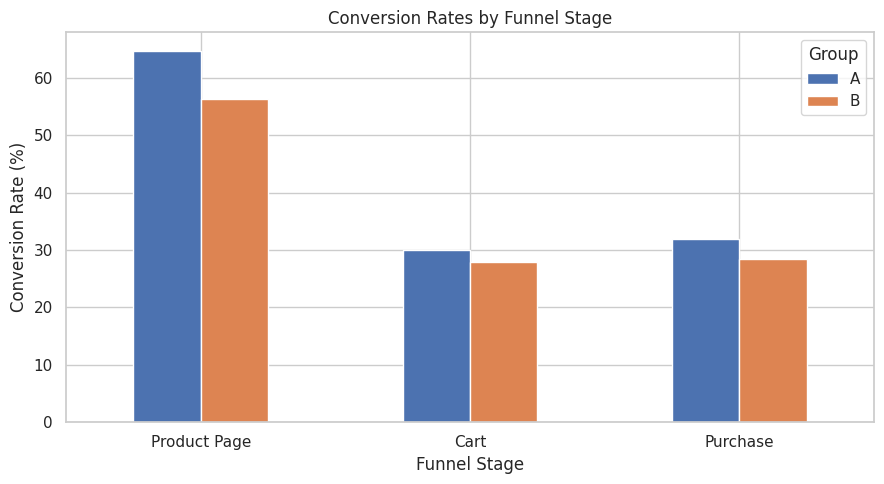

In [34]:
# Prepare conversion rates for visualization

stage_labels = {
    'product_page': 'Product Page',
    'product_cart': 'Cart',
    'purchase': 'Purchase'
}

conversion_plot = (
    conversion_summary
    .drop(index='login')
    .reindex(['product_page', 'product_cart', 'purchase'])
    .rename(index=stage_labels)
)

# Plot conversion rates by experimental group

ax = conversion_plot.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Conversion Rates by Funnel Stage')
plt.xlabel('Funnel Stage')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.tight_layout()
plt.show()

The control group consistently achieved higher conversion rates across all funnel stages. The largest difference was observed at the product page stage, where Group A reached 64.7% compared to 56.3% for Group B.

### Daily Event Activity

Daily event volume is visualized to assess whether user activity was consistently captured throughout the experiment period.

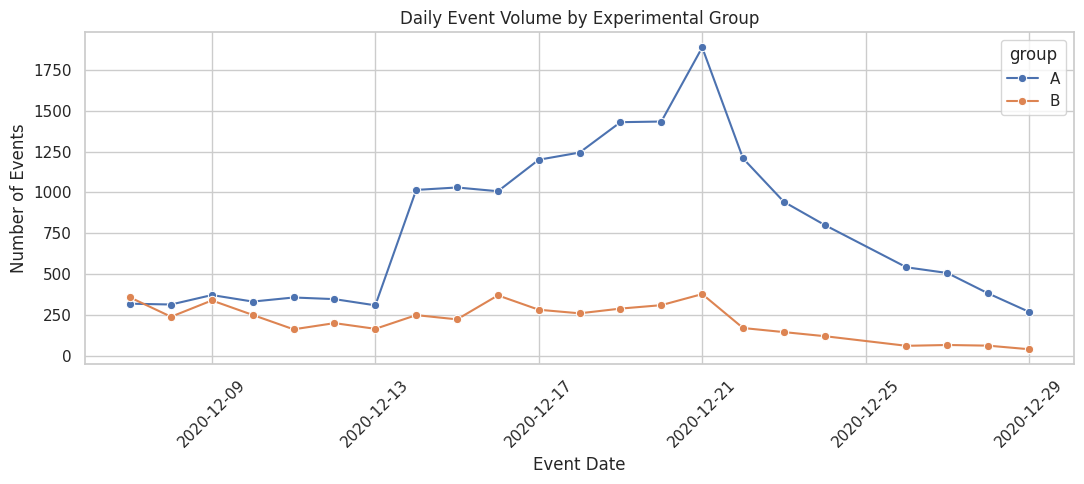

In [35]:
# Plot daily event volume by experimental group

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=events_by_day,
    x='event_date',
    y='events_count',
    hue='group',
    marker='o'
)

plt.title('Daily Event Volume by Experimental Group')
plt.xlabel('Event Date')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Event activity was observed throughout the entire experiment period for both groups. No major interruptions or abnormal gaps were detected, supporting the validity of the experiment timeline.

## Statistical Hypothesis Testing

### Conversion Rate Hypothesis Test
This test evaluates whether the difference in purchase conversion rates between the control group (A) and treatment group (B) is statistically significant.

A two-proportion Z-test is used with a significance level of **α = 0.05**.

- **H₀:** There is no statistically significant difference in purchase conversion rates between Group A and Group B.
- **H₁:** There is a statistically significant difference in purchase conversion rates between Group A and Group B.

In [36]:
# Extract login users and purchase users by group

n_A = funnel_by_group[
    (funnel_by_group['group'] == 'A') &
    (funnel_by_group['event_name'] == 'login')
]['user_id'].iloc[0]

n_B = funnel_by_group[
    (funnel_by_group['group'] == 'B') &
    (funnel_by_group['event_name'] == 'login')
]['user_id'].iloc[0]

x_A = funnel_by_group[
    (funnel_by_group['group'] == 'A') &
    (funnel_by_group['event_name'] == 'purchase')
]['user_id'].iloc[0]

x_B = funnel_by_group[
    (funnel_by_group['group'] == 'B') &
    (funnel_by_group['event_name'] == 'purchase')
]['user_id'].iloc[0]

p_A = x_A / n_A
p_B = x_B / n_B

print(f'Group A purchase conversion rate: {p_A:.2%}')
print(f'Group B purchase conversion rate: {p_B:.2%}')

Group A purchase conversion rate: 31.99%
Group B purchase conversion rate: 28.42%


In [37]:
# Two-proportion Z-test

p_combined = (x_A + x_B) / (n_A + n_B)

std_error = np.sqrt(
    p_combined * (1 - p_combined) *
    (1 / n_A + 1 / n_B)
)

z_stat = (p_B - p_A) / std_error
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f'Z-statistic: {z_stat:.4f}')
print(f'P-value: {p_value:.4f}')

Z-statistic: -1.9717
P-value: 0.0486


The purchase conversion rate was **31.99%** for Group A and **28.42%** for Group B.

The two-proportion Z-test produced a **Z-statistic of -1.9717** and a **p-value of 0.0486**.

Because the p-value is below the significance threshold of **0.05**, the null hypothesis is rejected. The results indicate a statistically significant difference in purchase conversion rates between the two groups.

However, the difference favors the control group (A), which achieved a higher purchase conversion rate than the treatment group (B). Therefore, the new recommendation system did not improve conversion performance and may have negatively impacted user behavior.

## Conclusions

This analysis evaluated the impact of a new recommendation system through an A/B test conducted among users in the EU region during the first 14 days after registration.

Key findings include:

- The final analytical sample contained 3,481 users, with 2,604 users in Group A and 877 users in Group B.
- Group A consistently outperformed Group B across all major funnel stages.
- Purchase conversion reached 31.99% in Group A compared to 28.42% in Group B.
- Users in Group A also demonstrated higher engagement, generating an average of 6.62 events per user versus 5.38 events per user in Group B.
- The two-proportion Z-test produced a p-value of 0.0486, indicating a statistically significant difference between the groups at the 5% significance level.
- Contrary to expectations, the observed difference favored the control group rather than the treatment group.

Overall, the results suggest that the new recommendation system did not achieve its intended objective of improving user conversion and engagement. Based on the available evidence, the current recommendation system performed more effectively than the tested alternative.

## Recommendations

Based on the results of this analysis, the following actions are recommended:

- Maintain the existing recommendation system rather than deploying the tested version, as the treatment group demonstrated lower engagement and conversion performance.

- Conduct a detailed review of the recommendation logic to identify potential factors that may have reduced user interaction and purchase behavior.

- Perform additional user behavior analysis to understand where users exposed to the new recommendation system disengaged from the conversion funnel.

- Consider running a follow-up experiment with revised recommendation strategies before making product-wide implementation decisions.

- Monitor conversion performance continuously after future recommendation updates to ensure that changes generate measurable business value.